In [ ]:
!pip install datasets
!pip install huggingface_hub
!pip install pandas

In [ ]:
from huggingface_hub import login
login()

In [ ]:
from datasets import load_dataset

dataset = load_dataset("Exploration-Lab/IL-TUR", "pcr")

print(dataset)

pcr/train_candidates-00000-of-00001.parq(…):   0%|          | 0.00/77.0M [00:00<?, ?B/s]

pcr/dev_candidates-00000-of-00001.parque(…):   0%|          | 0.00/25.1M [00:00<?, ?B/s]

pcr/test_candidates-00000-of-00001.parqu(…):   0%|          | 0.00/34.2M [00:00<?, ?B/s]

pcr/train_queries-00000-of-00001.parquet:   0%|          | 0.00/16.0M [00:00<?, ?B/s]

pcr/dev_queries-00000-of-00001.parquet:   0%|          | 0.00/2.83M [00:00<?, ?B/s]

...

Generating test_candidates split:   0%|          | 0/1727 [00:00<?, ? examples/s]

Generating train_queries split:   0%|          | 0/827 [00:00<?, ? examples/s]

Generating dev_queries split:   0%|          | 0/118 [00:00<?, ? examples/s]

Generating test_queries split:   0%|          | 0/237 [00:00<?, ? examples/s]

DatasetDict({
    train_candidates: Dataset({
        features: ['id', 'text', 'relevant_candidates'],
        num_rows: 4320
    })
    dev_candidates: Dataset({
        features: ['id', 'text', 'relevant_candidates'],
        num_rows: 1023
    })
    test_candidates: Dataset({
        features: ['id', 'text', 'relevant_candidates'],
        num_rows: 1727
    })
    train_queries: Dataset({
        features: ['id', 'text', 'relevant_candidates'],
        num_rows: 827
    })
    dev_queries: Dataset({
        features: ['id', 'text', 'relevant_candidates'],
        num_rows: 118
    })
    test_queries: Dataset({
        features: ['id', 'text', 'relevant_candidates'],
        num_rows: 237
    })
})


In [ ]:
dataset["train_queries"][0]

{'id': '0000000599',
 'text': ['PETITIONER: <NAME> Vs. RESPONDENT: ROOP SINGH RATHORE & OTHERS(and connected appeal) DATE OF JUDGMENT: 07/05/1963 BENCH: <NAME>, S.K. BENCH: <NAME>, S.K. SINHA, BHUVNESHWAR P.(CJ) DAYAL, RAGHUBAR AYYANGAR, <NAME> MUDHOLKAR, J.R. CITATION: 1964 AIR 1545 1964 SCR (3) 573 CITATOR INFO : R 1970 SC 765 (9) R 1971 SC 342 (6) RF 1974 SC1185 (16) F 1984 SC 305 (9,21) R 1991 SC1557 (20,22) ACT: Election Dispute-Joinder of -parties-Joinder of candi- date who did not contest-If invalidates eletion petition- "Copy", meaning of-Defects in verification and affidavit- Maintainability of petition- Representation of the People Act , 1951 , ss. 81 , 82 , 83 , 90 . HEADNOTE: The validity of the election of the appellant to <ORG> at the third general elections held in the month of February, 1962, was challenged by two of the electors of the constituency from which the appellant was elected, by filing election petitions for setting aside the election. The nomination paper of

In [ ]:
dataset["train_candidates"][0]

{'id': '0000000262',
 'text': ['JUDGMENT <NAME>, C.J. ',
  '1. The only point which has to be considered in this appeal is whether or not the lower appellate Court was wrong in admitting in evidence statements contained in two Exhibits, being Ex. 58 and 59 in the suit. ',
  '2. The case of the plaintiffs in the suit was that they were the owners of the suit plot marked A B C D E F and situated in Uppar Lane, Hukkeri, Belgium District. The defendants deny the title of the plaintiffs. In support of their case the plaintiffs produced the said Exhibits, being Exhibit 58 and Exhibit 59. Ex. 58 is dated 12-1-40 and Ex. 59 is dated 13-4-46. Ex. 58 is a sale-deed executed by one <NAME> and his minor sons in favour of the plaintiffs. ',
  'The subject matter of the said sale deed was a plot of land situated to south of the land in question in this suit. In that document it was recited that the northern boundary of the said land was a plot owned by the plaintiffs. Ex. 59 was a rent note executed

In [ ]:
import pandas as pd

queries = dataset["train_queries"].to_pandas()
candidates = dataset["train_candidates"].to_pandas()

queries.head()

,id,text,relevant_candidates
0,0000000599,[PETITIONER: <NAME> Vs. RESPONDENT: ROOP SINGH...,"[0001292810, 0001742283]"
1,0000002886,"[JUDGMENT <NAME>, J. , 1. This Civil Miscellan...","[0000066438, 0000087686, 0000091645, 000029237..."
2,0000009122,"[JUDGMENT <NAME>, J. , 1. These two are appeal...",[0000882637]
3,0000009256,"[ORDER <NAME>, J. , 1. The application filed b...","[0000128011, 0000144447, 0000333647, 000066543..."
4,0000010271,[PETITIONER: STATE OF U.P. Vs. RESPONDENT: KRI...,"[0000040914, 0000455716, 0000686491, 000093725..."


In [ ]:
print("Queries:", len(queries))
print("Candidates:", len(candidates))

Queries: 827
Candidates: 4320


In [ ]:
queries.columns

Index(['id', 'text', 'relevant_candidates'], dtype='object')

In [ ]:
candidates.columns

Index(['id', 'text', 'relevant_candidates'], dtype='object')

In [ ]:
print(queries["text"][0])

['PETITIONER: <NAME> Vs. RESPONDENT: ROOP SINGH RATHORE & OTHERS(and connected appeal) DATE OF JUDGMENT: 07/05/1963 BENCH: <NAME>, S.K. BENCH: <NAME>, S.K. SINHA, BHUVNESHWAR P.(CJ) DAYAL, RAGHUBAR AYYANGAR, <NAME> MUDHOLKAR, J.R. CITATION: 1964 AIR 1545 1964 SCR (3) 573 CITATOR INFO : R 1970 SC 765 (9) R 1971 SC 342 (6) RF 1974 SC1185 (16) F 1984 SC 305 (9,21) R 1991 SC1557 (20,22) ACT: Election Dispute-Joinder of -parties-Joinder of candi- date who did not contest-If invalidates eletion petition- "Copy", meaning of-Defects in verification and affidavit- Maintainability of petition- Representation of the People Act , 1951 , ss. 81 , 82 , 83 , 90 . HEADNOTE: The validity of the election of the appellant to <ORG> at the third general elections held in the month of February, 1962, was challenged by two of the electors of the constituency from which the appellant was elected, by filing election petitions for setting aside the election. The nomination paper of B, one of the two electors af

In [ ]:
print(dataset)

DatasetDict({
    train_candidates: Dataset({
        features: ['id', 'text', 'relevant_candidates'],
        num_rows: 4320
    })
    dev_candidates: Dataset({
        features: ['id', 'text', 'relevant_candidates'],
        num_rows: 1023
    })
    test_candidates: Dataset({
        features: ['id', 'text', 'relevant_candidates'],
        num_rows: 1727
    })
    train_queries: Dataset({
        features: ['id', 'text', 'relevant_candidates'],
        num_rows: 827
    })
    dev_queries: Dataset({
        features: ['id', 'text', 'relevant_candidates'],
        num_rows: 118
    })
    test_queries: Dataset({
        features: ['id', 'text', 'relevant_candidates'],
        num_rows: 237
    })
})


In [ ]:
queries["relevant_candidates"][0]

array(['0001292810', '0001742283'], dtype=object)

In [ ]:
train_queries = dataset["train_queries"].to_pandas()
train_candidates = dataset["train_candidates"].to_pandas()

In [ ]:
train_queries["relevant_candidates"][0]

array(['0001292810', '0001742283'], dtype=object)

In [ ]:
!pip install transformers
!pip install sentence-transformers
!pip install torch
!pip install scikit-learn

In [ ]:
import torch
import pandas as pd
import numpy as np

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
model = SentenceTransformer('all-MiniLM-L6-v2')

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [ ]:
def clean_text(text_list):
    if isinstance(text_list, list):
        return " ".join([str(x) for x in text_list if x is not None])
    return str(text_list)

query_texts = [clean_text(t) for t in train_queries["text"][:10].tolist()]
candidate_texts = [clean_text(t) for t in train_candidates["text"][:10].tolist()]

In [ ]:
query_embeddings = model.encode(query_texts)
candidate_embeddings = model.encode(candidate_texts)

In [ ]:
print(query_embeddings.shape)
print(candidate_embeddings.shape)

(10, 384)
(10, 384)


In [ ]:
similarity_matrix = cosine_similarity(query_embeddings, candidate_embeddings)
print(similarity_matrix)

[[0.47537002 1.0000001  0.5966632  0.30587053 0.53009224 0.45352814
  0.52826023 0.3757281  0.5139478  0.43858525]
 [0.6101955  0.5139478  0.39106315 0.4609524  0.59799385 0.4181917
  0.49243066 0.39873907 1.         0.49685922]
 [0.55731773 0.5500218  0.5096462  0.41019252 0.5758985  0.5179627
  0.67155683 0.5396383  0.4923438  0.64237165]
 [0.49738282 0.48652527 0.47919154 0.39078778 0.5580042  0.45305848
  0.5048648  0.34161127 0.5369965  0.5084875 ]
 [0.4929481  0.5569258  0.42253906 0.30413306 0.47452474 0.41661763
  0.51691854 0.48682886 0.39351717 0.460855  ]
 [0.43782377 0.77894425 0.53387284 0.29435164 0.5483203  0.43519425
  0.5141016  0.36395693 0.5048824  0.4311725 ]
 [0.5986751  0.5383197  0.43784347 0.55297923 0.5823865  0.46994624
  0.5373087  0.44004935 0.53711855 0.60468864]
 [0.53672683 0.35211182 0.3926523  0.40205604 0.4516706  0.41841874
  0.52974504 0.47766256 0.49623176 0.548566  ]
 [0.43914583 0.37056488 0.40153062 0.50753796 0.31583112 0.3120321
  0.4359579  0.

In [ ]:
best_match = np.argmax(similarity_matrix[0])

print("Query:")
print(query_texts[0])

print("\nBest Candidate:")
print(candidate_texts[best_match])

Query:
['PETITIONER: <NAME> Vs. RESPONDENT: ROOP SINGH RATHORE & OTHERS(and connected appeal) DATE OF JUDGMENT: 07/05/1963 BENCH: <NAME>, S.K. BENCH: <NAME>, S.K. SINHA, BHUVNESHWAR P.(CJ) DAYAL, RAGHUBAR AYYANGAR, <NAME> MUDHOLKAR, J.R. CITATION: 1964 AIR 1545 1964 SCR (3) 573 CITATOR INFO : R 1970 SC 765 (9) R 1971 SC 342 (6) RF 1974 SC1185 (16) F 1984 SC 305 (9,21) R 1991 SC1557 (20,22) ACT: Election Dispute-Joinder of -parties-Joinder of candi- date who did not contest-If invalidates eletion petition- "Copy", meaning of-Defects in verification and affidavit- Maintainability of petition- Representation of the People Act , 1951 , ss. 81 , 82 , 83 , 90 . HEADNOTE: The validity of the election of the appellant to <ORG> at the third general elections held in the month of February, 1962, was challenged by two of the electors of the constituency from which the appellant was elected, by filing election petitions for setting aside the election. The nomination paper of B, one of the two elec

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!mkdir -p /content/drive/MyDrive/TUR_Project

In [ ]:
from datasets import load_dataset
import pandas as pd

dataset = load_dataset("Exploration-Lab/IL-TUR", "pcr")

train_queries = dataset["train_queries"].to_pandas()
train_candidates = dataset["train_candidates"].to_pandas()

In [ ]:
candidate_texts = train_candidates["text"].tolist()

len(candidate_texts)

4320

In [ ]:
candidate_texts = [" ".join(text_list) for text_list in train_candidates["text"].tolist()]

candidate_embeddings = model.encode(
    candidate_texts,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

Batches:   0%|          | 0/135 [00:00<?, ?it/s]

In [ ]:
candidate_embeddings.shape

(4320, 384)

In [ ]:
import numpy as np

np.save(
    "/content/drive/MyDrive/TUR_Project/candidate_embeddings.npy",
    candidate_embeddings
)

In [ ]:
train_candidates.to_csv(
    "/content/drive/MyDrive/TUR_Project/candidates.csv",
    index=False
)

In [ ]:
query_texts = [" ".join(text_list) for text_list in train_queries["text"].tolist()]

query_embeddings = model.encode(
    query_texts,
    batch_size=32,
    show_progress_bar=True,
    convert_to_numpy=True
)

Batches:   0%|          | 0/26 [00:00<?, ?it/s]

In [ ]:
query_embeddings.shape

(827, 384)

In [ ]:
np.save(
    "/content/drive/MyDrive/TUR_Project/query_embeddings.npy",
    query_embeddings
)

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(
    query_embeddings,
    candidate_embeddings
)

In [ ]:
top5 = similarity_matrix[0].argsort()[-5:][::-1]

top5

array([   1, 2535, 2125,  600,   26])

In [ ]:
for i in top5:
    print("Case ID:", train_candidates.iloc[i]["id"])
    print("Text:", train_candidates.iloc[i]["text"][:300])
    print("\n")

Case ID: 0000000599
Text: ['PETITIONER: <NAME> Vs. RESPONDENT: ROOP SINGH RATHORE & OTHERS(and connected appeal) DATE OF JUDGMENT: 07/05/1963 BENCH: <NAME>, S.K. BENCH: <NAME>, S.K. SINHA, BHUVNESHWAR P.(CJ) DAYAL, RAGHUBAR AYYANGAR, <NAME> MUDHOLKAR, J.R. CITATION: 1964 AIR 1545 1964 SCR (3) 573 CITATOR INFO : R 1970 SC 765 (9) R 1971 SC 342 (6) RF 1974 SC1185 (16) F 1984 SC 305 (9,21) R 1991 SC1557 (20,22) ACT: Election Dispute-Joinder of -parties-Joinder of candi- date who did not contest-If invalidates eletion petition- "Copy", meaning of-Defects in verification and affidavit- Maintainability of petition- Representation of the People Act , 1951 , ss. 81 , 82 , 83 , 90 . HEADNOTE: The validity of the election of the appellant to <ORG> at the third general elections held in the month of February, 1962, was challenged by two of the electors of the constituency from which the appellant was elected, by filing election petitions for setting aside the election. The nomination paper of B, 

In [ ]:
relevant_lists = train_queries["relevant_candidates"].tolist()

In [ ]:
candidate_ids = train_candidates["id"].tolist()

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(
    query_embeddings,
    candidate_embeddings
)

In [ ]:
recall_scores = []
mrr_scores = []

for i in range(len(train_queries)):

    relevant = relevant_lists[i]

    similarities = similarity_matrix[i]

    top5_indices = similarities.argsort()[-5:][::-1]

    top5_ids = [candidate_ids[idx] for idx in top5_indices]

    # Recall@5
    found = 0
    for r in relevant:
        if r in top5_ids:
            found += 1

    recall = found / len(relevant)
    recall_scores.append(recall)

    # MRR
    rank = 0
    for idx, cid in enumerate(top5_ids):
        if cid in relevant:
            rank = idx + 1
            break

    if rank > 0:
        mrr_scores.append(1 / rank)
    else:
        mrr_scores.append(0)

In [ ]:
import numpy as np

print("Recall@5:", np.mean(recall_scores))
print("MRR:", np.mean(mrr_scores))

Recall@5: 0.07351162402037087
MRR: 0.1067714631197098


In [ ]:
# ================================
# DAY 5: LEGALBERT IMPLEMENTATION
# ================================

# Install libraries
!pip install transformers sentence-transformers datasets torch scikit-learn

# ================================
# Import Libraries
# ================================

import numpy as np
import pandas as pd
import torch

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModel
from sklearn.metrics.pairwise import cosine_similarity

print("Libraries Loaded")

# ================================
# Load TUR Dataset
# ================================

dataset = load_dataset("Exploration-Lab/IL-TUR", "pcr")

train_queries = dataset["train_queries"].to_pandas()
train_candidates = dataset["train_candidates"].to_pandas()

print("Queries:", train_queries.shape)
print("Candidates:", train_candidates.shape)

# ================================
# Load LegalBERT
# ================================

model_name = "nlpaueb/legal-bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

device = "cuda" if torch.cuda.is_available() else "cpu"
model = model.to(device)

print("LegalBERT Loaded on", device)

# ================================
# Embedding Function
# ================================

def get_embeddings(texts, batch_size=16):

    embeddings = []

    for i in range(0, len(texts), batch_size):

        batch = texts[i:i+batch_size]
        # Join the list of strings for each text into a single string
        processed_batch = [" ".join(text_list) for text_list in batch]

        tokens = tokenizer(
            processed_batch,
            padding=True,
            truncation=True,
            max_length=512,
            return_tensors="pt"
        )

        tokens = {k: v.to(device) for k, v in tokens.items()}

        with torch.no_grad():
            outputs = model(**tokens)

        cls_embeddings = outputs.last_hidden_state[:,0,:]

        embeddings.append(cls_embeddings.cpu().numpy())

        print(f"Processed {i+batch_size}/{len(texts)}")

    return np.vstack(embeddings)

# ================================
# Generate Candidate Embeddings
# ================================

candidate_texts = train_candidates["text"].tolist()

print("Generating Candidate Embeddings...")

candidate_embeddings = get_embeddings(candidate_texts)

print("Candidate Embeddings Shape:", candidate_embeddings.shape)

# ================================
# Generate Query Embeddings
# ================================

query_texts = train_queries["text"].tolist()

print("Generating Query Embeddings...")

query_embeddings = get_embeddings(query_texts)

print("Query Embeddings Shape:", query_embeddings.shape)

# ================================
# Similarity Matrix
# ================================

print("Computing Similarity...")

similarity_matrix = cosine_similarity(
    query_embeddings,
    candidate_embeddings
)

print("Similarity Done")

# ================================
# Evaluation
# ================================

relevant_lists = train_queries["relevant_candidates"].tolist()
candidate_ids = train_candidates["id"].tolist()

recall_scores = []
mrr_scores = []

for i in range(len(train_queries)):

    relevant = relevant_lists[i]
    similarities = similarity_matrix[i]

    top5_indices = similarities.argsort()[-5:][::-1]
    top5_ids = [candidate_ids[idx] for idx in top5_indices]

    # Recall@5
    found = 0
    for r in relevant:
        if r in top5_ids:
            found += 1

    recall = found / len(relevant)
    recall_scores.append(recall)

    # MRR
    rank = 0
    for idx, cid in enumerate(top5_ids):
        if cid in relevant:
            rank = idx + 1
            break

    if rank > 0:
        mrr_scores.append(1 / rank)
    else:
        mrr_scores.append(0)

# ================================
# Final Results
# ================================

print("\n====================")
print("LEGALBERT RESULTS")
print("====================")

print("Recall@5:", np.mean(recall_scores))
print("MRR:", np.mean(mrr_scores))


Libraries Loaded
Queries: (827, 3)
Candidates: (4320, 3)


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

BertModel LOAD REPORT from: nlpaueb/legal-bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


LegalBERT Loaded on cuda
Generating Candidate Embeddings...
Processed 16/4320
Processed 32/4320
Processed 48/4320
Processed 64/4320
Processed 80/4320
Processed 96/4320
Processed 112/4320
Processed 128/4320
Processed 144/4320
Processed 160/4320
Processed 176/4320
Processed 192/4320
Processed 208/4320
Processed 224/4320
Processed 240/4320
Processed 256/4320
Processed 272/4320
Processed 288/4320
Processed 304/4320
Processed 320/4320
Processed 336/4320
Processed 352/4320
Processed 368/4320
Processed 384/4320
Processed 400/4320
Processed 416/4320
Processed 432/4320
Processed 448/4320
Processed 464/4320
Processed 480/4320
Processed 496/4320
Processed 512/4320
Processed 528/4320
Processed 544/4320
Processed 560/4320
Processed 576/4320
Processed 592/4320
Processed 608/4320
Processed 624/4320
Processed 640/4320
Processed 656/4320
Processed 672/4320
Processed 688/4320
Processed 704/4320
Processed 720/4320
Processed 736/4320
Processed 752/4320
Processed 768/4320
Processed 784/4320
Processed 800/4

In [ ]:
# ==========================================
# DAY 6: Fine-tuning LegalBERT (FINAL FIXED)
# ==========================================

!pip install -q sentence-transformers datasets transformers torch scikit-learn accelerate

# ==========================================
# Imports
# ==========================================

import pandas as pd
import numpy as np
import torch
import gc

from datasets import load_dataset
from sentence_transformers import SentenceTransformer, InputExample, losses, models
from torch.utils.data import DataLoader
from sklearn.metrics.pairwise import cosine_similarity

print("Libraries Loaded")

# ==========================================
# Device Setup
# ==========================================

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using Device:", device)

torch.cuda.empty_cache()
gc.collect()

# ==========================================
# Load Dataset
# ==========================================

dataset = load_dataset("Exploration-Lab/IL-TUR", "pcr")

train_queries = dataset["train_queries"].to_pandas()
train_candidates = dataset["train_candidates"].to_pandas()

print("Queries:", train_queries.shape)
print("Candidates:", train_candidates.shape)

# ==========================================
# Candidate Mapping
# ==========================================

candidate_map = {
    row["id"]: " ".join(row["text"])
    for _, row in train_candidates.iterrows()
}

print("Candidate Mapping Ready")

# ==========================================
# Training Pairs (NO LABEL NOW)
# ==========================================

train_examples = []

for _, row in train_queries.iterrows():

    query_text = " ".join(row["text"])

    for rel in row["relevant_candidates"]:
        if rel in candidate_map:

            train_examples.append(
                InputExample(
                    texts=[query_text, candidate_map[rel]]
                )
            )

print("Training Pairs:", len(train_examples))

# ==========================================
# Clear Memory
# ==========================================

torch.cuda.empty_cache()
gc.collect()

# ==========================================
# Load LegalBERT Properly
# ==========================================

word_embedding_model = models.Transformer(
    "nlpaueb/legal-bert-base-uncased",
    max_seq_length=256
)

pooling_model = models.Pooling(
    word_embedding_model.get_word_embedding_dimension()
)

model = SentenceTransformer(
    modules=[word_embedding_model, pooling_model],
    device=device
)

print("LegalBERT Loaded")

# ==========================================
# DataLoader
# ==========================================

train_dataloader = DataLoader(
    train_examples,
    shuffle=True,
    batch_size=8
)

# ✅ IMPORTANT CHANGE
train_loss = losses.MultipleNegativesRankingLoss(model)

print("Training Setup Ready")

# ==========================================
# Training (MORE EPOCHS)
# ==========================================

print("Training Started...")

model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    epochs=3,              # increased
    warmup_steps=100,
    use_amp=True,
    show_progress_bar=True
)

print("Training Completed")

# ==========================================
# Save Model
# ==========================================

model.save("/content/legalbert_tur_model")

print("Model Saved")

# ==========================================
# Clear GPU
# ==========================================

torch.cuda.empty_cache()
gc.collect()

# ==========================================
# Embeddings (CPU to avoid crash)
# ==========================================

candidate_texts = [" ".join(t) for t in train_candidates["text"].tolist()]
query_texts = [" ".join(t) for t in train_queries["text"].tolist()]

candidate_embeddings = model.encode(
    candidate_texts,
    batch_size=32,
    convert_to_numpy=True,
    show_progress_bar=True,
    device="cpu"
)

query_embeddings = model.encode(
    query_texts,
    batch_size=32,
    convert_to_numpy=True,
    show_progress_bar=True,
    device="cpu"
)

print("Embeddings Done")

# ==========================================
# Similarity
# ==========================================

similarity_matrix = cosine_similarity(query_embeddings, candidate_embeddings)

# ==========================================
# Evaluation
# ==========================================

relevant_lists = train_queries["relevant_candidates"].tolist()
candidate_ids = train_candidates["id"].tolist()

recall_scores = []
mrr_scores = []

for i in range(len(train_queries)):

    sims = similarity_matrix[i]
    top5_idx = sims.argsort()[-5:][::-1]
    top5_ids = [candidate_ids[j] for j in top5_idx]

    relevant = relevant_lists[i]

    # Recall@5
    hit = sum([1 for r in relevant if r in top5_ids])
    recall_scores.append(hit / len(relevant))

    # MRR
    rank = 0
    for idx, cid in enumerate(top5_ids):
        if cid in relevant:
            rank = idx + 1
            break

    mrr_scores.append(1/rank if rank > 0 else 0)

# ==========================================
# Results
# ==========================================

print("\n==============================")
print("FINAL FINE-TUNED RESULTS")
print("==============================")

print("Recall@5:", np.mean(recall_scores))
print("MRR:", np.mean(mrr_scores))

/tmp/ipykernel_1816/1153296199.py:17: DeprecationWarning: Importing from 'sentence_transformers.losses' is deprecated and will be removed in a future version. Please use 'sentence_transformers.sentence_transformer.losses' instead.
  from sentence_transformers import SentenceTransformer, InputExample, losses, models


Libraries Loaded
Using Device: cuda
Queries: (827, 3)
Candidates: (4320, 3)
Candidate Mapping Ready
Training Pairs: 5308


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: nlpaueb/legal-bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/tmp/ipykernel_1816/1153296199.py:94: FutureWarning: The `get_word_embedding_dimension` method has been renamed to `get_embedding_dimensi

LegalBERT Loaded
Training Setup Ready
Training Started...


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model Saved


Batches:   0%|          | 0/135 [00:00<?, ?it/s]

Batches:   0%|          | 0/26 [00:00<?, ?it/s]

Embeddings Done

FINAL FINE-TUNED RESULTS
Recall@5: 0.156030121816266
MRR: 0.18855300282144297


Graph Neural Network (GNN) Integration

In [ ]:
# ==========================================
# DAY 7 FINAL: FAST + CORRECT GNN
# ==========================================

!pip install -q torch-geometric

import torch
import numpy as np
import pandas as pd
import gc

from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

print("Libraries Loaded")

# ==========================================
# DEVICE
# ==========================================

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

torch.cuda.empty_cache()
gc.collect()

# ==========================================
# LOAD DATA
# ==========================================

dataset = load_dataset("Exploration-Lab/IL-TUR", "pcr")

queries = dataset["train_queries"].to_pandas()
candidates = dataset["train_candidates"].to_pandas()

# ==========================================
# CLEAN TEXT
# ==========================================

def clean(x):
    return " ".join(x) if isinstance(x, list) else str(x)

candidate_texts = [clean(x) for x in candidates["text"]]
query_texts = [clean(x) for x in queries["text"]]

# ==========================================
# LOAD YOUR FINE-TUNED MODEL
# ==========================================

model = SentenceTransformer("/content/legalbert_tur_model")

# ==========================================
# EMBEDDINGS
# ==========================================

candidate_embeddings = model.encode(
    candidate_texts,
    batch_size=64,
    convert_to_numpy=True,
    device=device,
    show_progress_bar=True
)

query_embeddings = model.encode(
    query_texts,
    batch_size=64,
    convert_to_numpy=True,
    device=device,
    show_progress_bar=True
)

print("Embeddings Done")

# ==========================================
# BUILD GRAPH (ONLY CANDIDATES)
# ==========================================

TOP_K = 5

sim_matrix = cosine_similarity(candidate_embeddings, candidate_embeddings)

edges = []

for i in range(len(sim_matrix)):
    top_k_idx = np.argsort(sim_matrix[i])[-TOP_K:]

    for j in top_k_idx:
        if i != j:
            edges.append([i, j])

edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous().to(device)

print("Edges:", edge_index.shape)

# ==========================================
# NODE FEATURES
# ==========================================

x = torch.tensor(candidate_embeddings, dtype=torch.float).to(device)

data = Data(x=x, edge_index=edge_index)

# ==========================================
# GNN MODEL
# ==========================================

class FastGNN(torch.nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.conv1 = GCNConv(in_channels, 128)
        self.conv2 = GCNConv(128, 128)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = torch.relu(x)
        x = self.conv2(x, edge_index)
        return x

model_gnn = FastGNN(x.shape[1]).to(device)

optimizer = torch.optim.Adam(model_gnn.parameters(), lr=0.01)

print("GNN Ready")

# ==========================================
# TRAINING (FAST)
# ==========================================

EPOCHS = 4

for epoch in range(EPOCHS):
    model_gnn.train()
    optimizer.zero_grad()

    out = model_gnn(data.x, data.edge_index)

    loss = ((out[edge_index[0]] - out[edge_index[1]])**2).mean()

    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item()}")

print("GNN Training Done")

# ==========================================
# GET NEW EMBEDDINGS
# ==========================================

model_gnn.eval()
candidate_new = model_gnn(data.x, data.edge_index).detach().cpu().numpy()

# ==========================================
# 🔥 FIX: TRANSFORM QUERIES ALSO
# ==========================================

query_tensor = torch.tensor(query_embeddings, dtype=torch.float).to(device)

# dummy edges (no graph for queries)
dummy_edge = torch.empty((2, 0), dtype=torch.long).to(device)

query_new = model_gnn(query_tensor, dummy_edge).detach().cpu().numpy()

print("Query transformed")

# ==========================================
# EVALUATION
# ==========================================

sim_matrix = cosine_similarity(query_new, candidate_new)

relevant_lists = queries["relevant_candidates"].tolist()
candidate_ids = candidates["id"].tolist()

recall_scores = []
mrr_scores = []

for i in range(len(queries)):

    sims = sim_matrix[i]
    top5_idx = sims.argsort()[-5:][::-1]
    top5_ids = [candidate_ids[j] for j in top5_idx]

    relevant = relevant_lists[i]

    hit = sum([1 for r in relevant if r in top5_ids])
    recall_scores.append(hit / len(relevant))

    rank = 0
    for idx, cid in enumerate(top5_ids):
        if cid in relevant:
            rank = idx + 1
            break

    mrr_scores.append(1/rank if rank > 0 else 0)

print("\n==============================")
print("FINAL GNN RESULTS")
print("==============================")

print("Recall@5:", np.mean(recall_scores))
print("MRR:", np.mean(mrr_scores))

Libraries Loaded
Device: cuda


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/68 [00:00<?, ?it/s]

Batches:   0%|          | 0/13 [00:00<?, ?it/s]

Embeddings Done
Edges: torch.Size([2, 17280])
GNN Ready
Epoch 1, Loss: 0.07142527401447296
Epoch 2, Loss: 0.04372319206595421
Epoch 3, Loss: 0.0033733579330146313
Epoch 4, Loss: 1.0037527317763306e-05
GNN Training Done
Query transformed

FINAL GNN RESULTS
Recall@5: 0.000477956972017716
MRR: 0.0024586860137041514


Building Graph...
Nodes: 50
Edges: 8


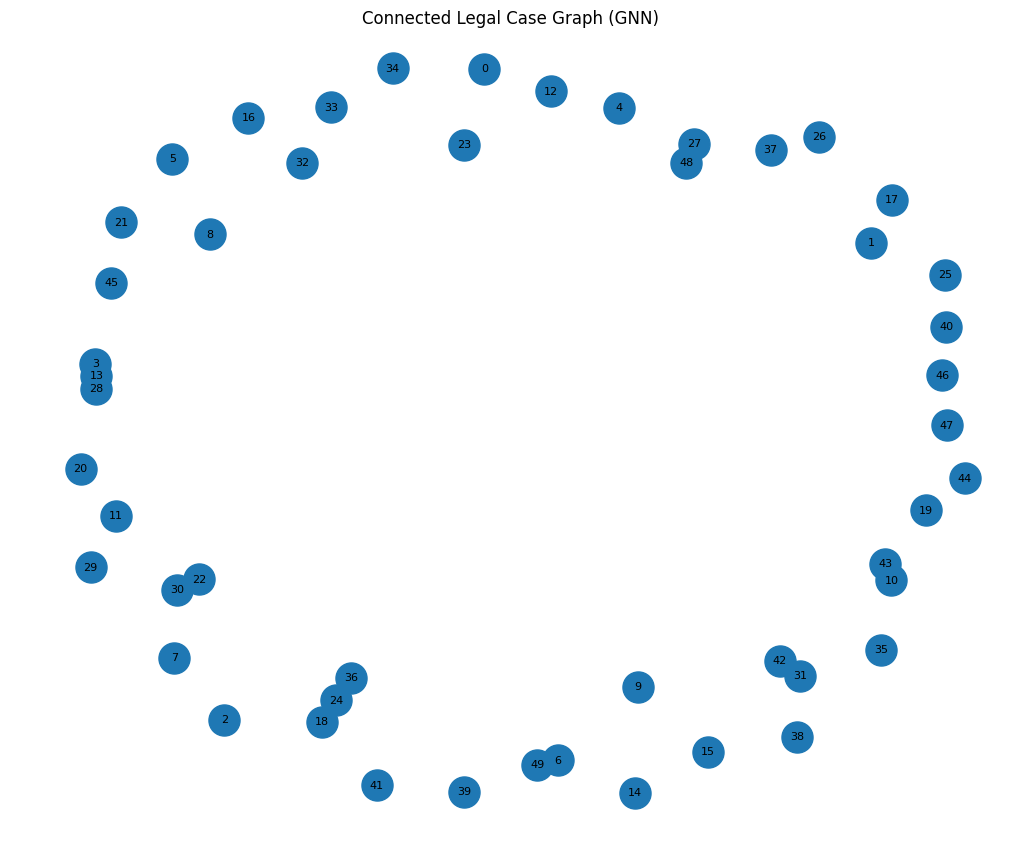

In [ ]:
# ==========================================
# VISUALIZE CONNECTED GRAPH (CLEAR)
# ==========================================

!pip install networkx matplotlib -q

import networkx as nx
import matplotlib.pyplot as plt

print("Building Graph...")

G = nx.Graph()

# 🔥 IMPORTANT: reduce nodes for visibility
NUM_NODES = 50   # keep small for clarity

# Add nodes
for i in range(NUM_NODES):
    G.add_node(i)

# Add edges (only subset)
edge_list = edge_index.t().cpu().numpy()

for src, dst in edge_list:
    if src < NUM_NODES and dst < NUM_NODES:
        G.add_edge(src, dst)

print("Nodes:", G.number_of_nodes())
print("Edges:", G.number_of_edges())

# ==========================================
# DRAW GRAPH (CONNECTED)
# ==========================================

plt.figure(figsize=(10, 8))

pos = nx.spring_layout(G, seed=42)  # better layout

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=500,
    font_size=8
)

plt.title("Connected Legal Case Graph (GNN)")
plt.show()

checking the case :

In [ ]:
# ==========================================
# FINAL SYSTEM: USER INPUT → CASE MATCHING
# ==========================================

from sklearn.metrics.pairwise import cosine_similarity

def predict_case(user_input, top_k=5):

    # Step 1: Encode input
    user_embedding = model.encode(
        [user_input],
        convert_to_numpy=True
    )

    # Step 2: Convert to tensor
    user_tensor = torch.tensor(user_embedding, dtype=torch.float).to(device)

    # Step 3: Pass through GNN
    dummy_edge = torch.empty((2, 0), dtype=torch.long).to(device)

    user_new = model_gnn(user_tensor, dummy_edge).detach().cpu().numpy()

    # Step 4: Similarity with candidates
    sims = cosine_similarity(user_new, candidate_new)[0]

    # Step 5: Top results
    top_idx = sims.argsort()[-top_k:][::-1]

    print("\n🔍 USER QUERY:")
    print(user_input)

    print("\n🏆 TOP MATCHED LEGAL CASES:\n")

    for rank, idx in enumerate(top_idx):

        print(f"Rank {rank+1}")
        print("Case ID:", candidates.iloc[idx]["id"])
        print("Score:", sims[idx])
        print("Case Text:", " ".join(candidates.iloc[idx]["text"])[:300])
        print("-"*60)


# ==========================================
# TEST
# ==========================================

predict_case("my land was taken illegally")


🔍 USER QUERY:
my land was taken illegally

🏆 TOP MATCHED LEGAL CASES:

Rank 1
Case ID: 0000014936
Score: 0.99999994
Case Text: <NAME>, J.  1. The facts out of which this appeal arises are these : Defendants 1 to 4 are a firm of merchants trading in Madura, Defendant 5 and his undivided son, defendants, are merchants carrying on business in Tiruvalur. The plaintiffs are cloth merchants in Conjeeveram. Defendants 1 to 4 becam
------------------------------------------------------------
Rank 2
Case ID: 0000014789
Score: 0.99999994
Case Text: JUDGMENT <NAME>, C.J.  1. A preliminary objection has been taken by Mr. <NAME> on behalf of respondent No. 3 that this appeal is not maintainable. In my opinion, the objection ought to prevail.  2. The appeal is against an order of <NAME>, J., dated 19-3-1957, whereby he allowed respondent No. 3, Sm
------------------------------------------------------------
Rank 3
Case ID: 0000014720
Score: 0.99999994
Case Text: PETITIONER: <NAME> Vs. RESPONDENT: S


🔍 Query: property dispute over land ownership between two families


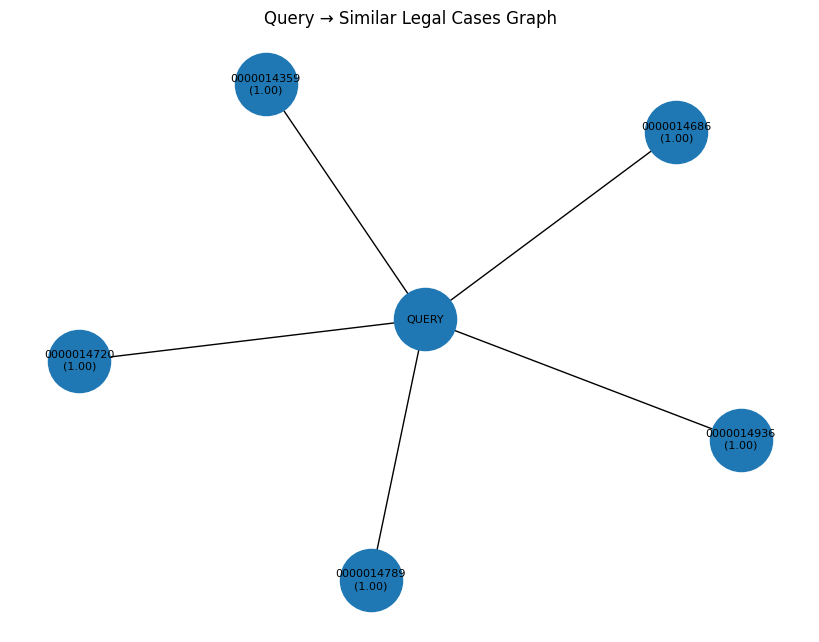


Top Matches:

Score: 0.99999994
Case ID: 0000014936
Text: ['<NAME>, J. '
 "1. The facts out of which this appeal arises are these : Defendants 1 to 4 are a firm of merchants trading in Madura, Defendant 5 and his undivided son, defendants, are merchants carr
--------------------------------------------------
Score: 0.99999994
Case ID: 0000014789
Text: ['JUDGMENT <NAME>, C.J. '
 '1. A preliminary objection has been taken by Mr. <NAME> on behalf of respondent No. 3 that this appeal is not maintainable. In my opinion, the objection ought to prevail. '
--------------------------------------------------
Score: 0.99999994
Case ID: 0000014720
Text: ["PETITIONER: <NAME> Vs. RESPONDENT: SADASIVA TRIPATHI DATE OF JUDGMENT: 15/07/1968 BENCH: SHAH, J.C. BENCH: SHAH, J.C. BHARGAVA, VISHISHTHA CITATION: 1969 AIR 302 1969 SCR (1) 351 ACT: Representation
--------------------------------------------------
Score: 0.99999994
Case ID: 0000014686
Text: ['JUDGMENT '
 '1. The plaintift is the appellant befo

In [ ]:
# ==========================================
# GRAPH FOR INPUT CASE (QUERY-BASED GRAPH)
# ==========================================

!pip install networkx matplotlib -q

import networkx as nx
import matplotlib.pyplot as plt

def visualize_query_graph(query, top_k=5):

    print("\n🔍 Query:", query)

    # Step 1: Encode query
    query_emb = model.encode([query], convert_to_numpy=True)

    query_tensor = torch.tensor(query_emb, dtype=torch.float).to(device)
    dummy_edge = torch.empty((2, 0), dtype=torch.long).to(device)

    query_new = model_gnn(query_tensor, dummy_edge).detach().cpu().numpy()

    # Step 2: Similarity
    sims = cosine_similarity(query_new, candidate_new)[0]
    top_idx = sims.argsort()[-top_k:][::-1]

    # Step 3: Build Graph
    G = nx.Graph()

    # Add query node
    G.add_node("QUERY")

    # Add top cases
    for i in top_idx:
        case_id = candidate_ids[i]
        score = float(sims[i])

        label = f"{case_id}\n({score:.2f})"

        G.add_node(label)

        # connect query to case
        G.add_edge("QUERY", label)

    # Step 4: Draw Graph
    plt.figure(figsize=(8, 6))

    pos = nx.spring_layout(G, seed=42)

    nx.draw(
        G,
        pos,
        with_labels=True,
        node_size=2000,
        font_size=8
    )

    plt.title("Query → Similar Legal Cases Graph")
    plt.show()

    # Step 5: Print results also
    print("\nTop Matches:\n")
    for i in top_idx:
        print("Score:", sims[i])
        print("Case ID:", candidate_ids[i])
        print("Text:", candidate_texts[i][:200])
        print("-"*50)


# ==========================================
# TEST IT
# ==========================================

visualize_query_graph("property dispute over land ownership between two families")